t-SNE on the same digits dataset used in `21-pca/`, for a direct comparison. t-SNE is non-linear and built specifically for 2D/3D visualization — it preserves local neighborhood structure rather than global variance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target
X_scaled = StandardScaler().fit_transform(X)

# PCA 2D from the previous notebook, recomputed here for side-by-side comparison
pca_2d = PCA(n_components=2).fit_transform(X_scaled)

In [2]:
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_scaled)
tsne_time = time.time() - t0
print(f"t-SNE took {tsne_time:.1f}s for {X.shape[0]} points")

t-SNE took 3.7s for 1797 points


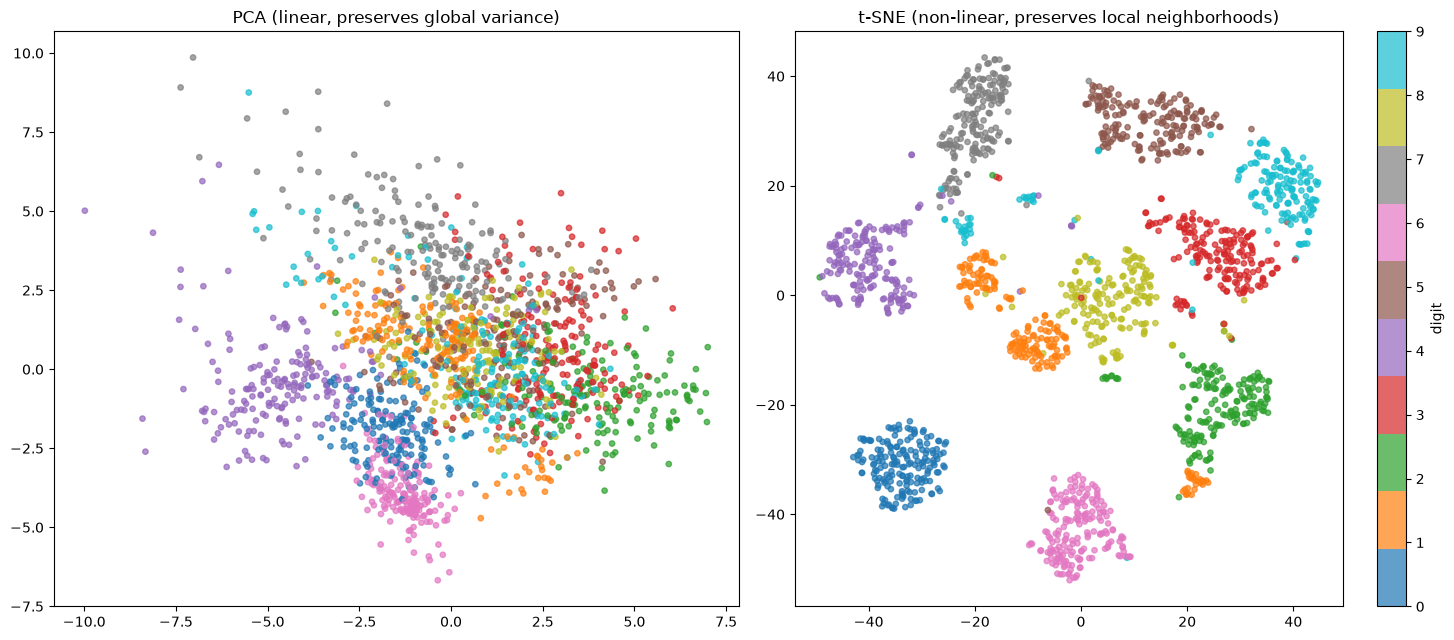

t-SNE typically produces much tighter, more visually separated clusters per digit class than PCA.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

sc0 = axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title('PCA (linear, preserves global variance)')

sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
axes[1].set_title('t-SNE (non-linear, preserves local neighborhoods)')

plt.colorbar(sc1, ax=axes[1], label='digit')
plt.tight_layout()
plt.show()
print("t-SNE typically produces much tighter, more visually separated clusters per digit class than PCA.")

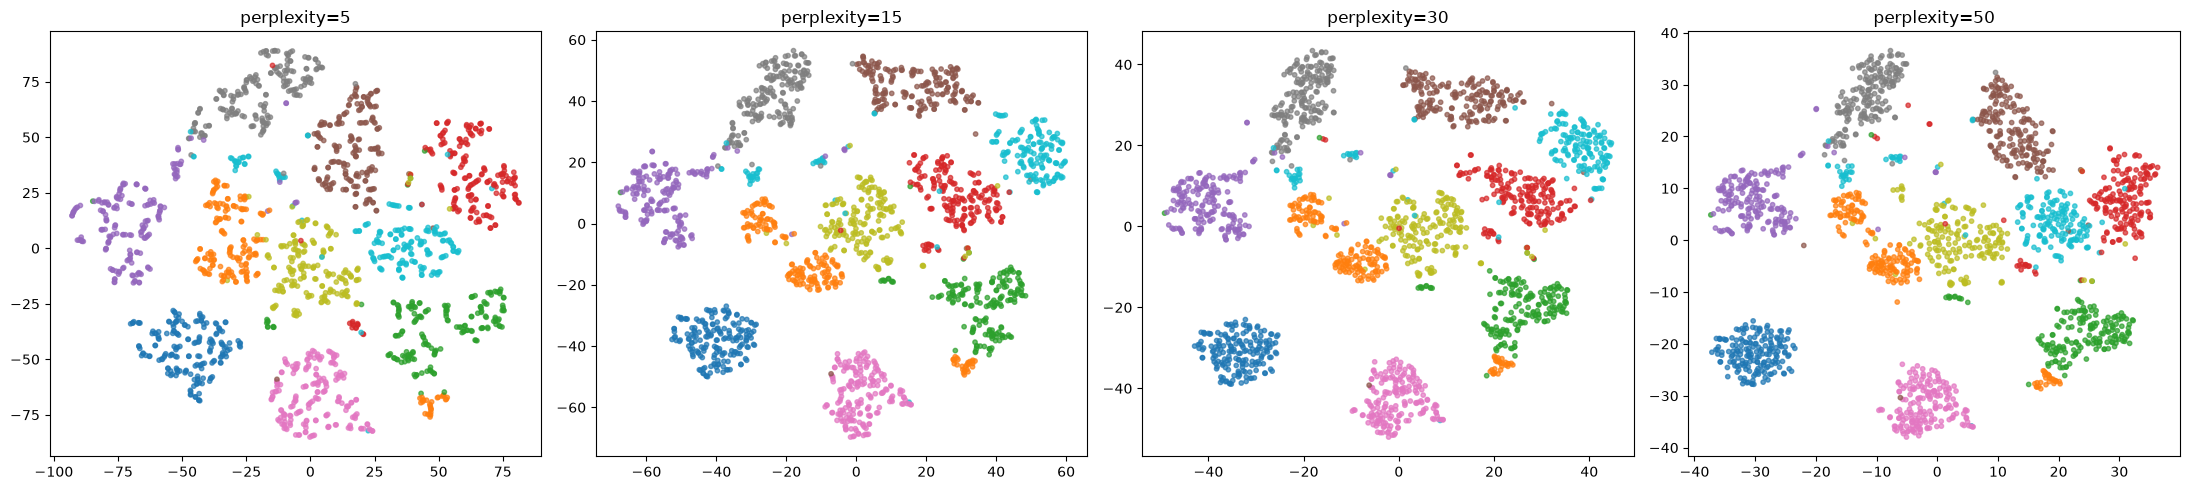

Low perplexity -> focuses on very local structure, can fragment classes into sub-clusters.
High perplexity -> considers more neighbors, smoother but can blur fine distinctions.


In [4]:
# Perplexity controls the effective neighborhood size t-SNE tries to preserve
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, len(perplexities), figsize=(22, 5))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42, init='pca')
    X_p = tsne_p.fit_transform(X_scaled)
    ax.scatter(X_p[:, 0], X_p[:, 1], c=y, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(f'perplexity={perp}')

plt.tight_layout()
plt.show()
print("Low perplexity -> focuses on very local structure, can fragment classes into sub-clusters.")
print("High perplexity -> considers more neighbors, smoother but can blur fine distinctions.")

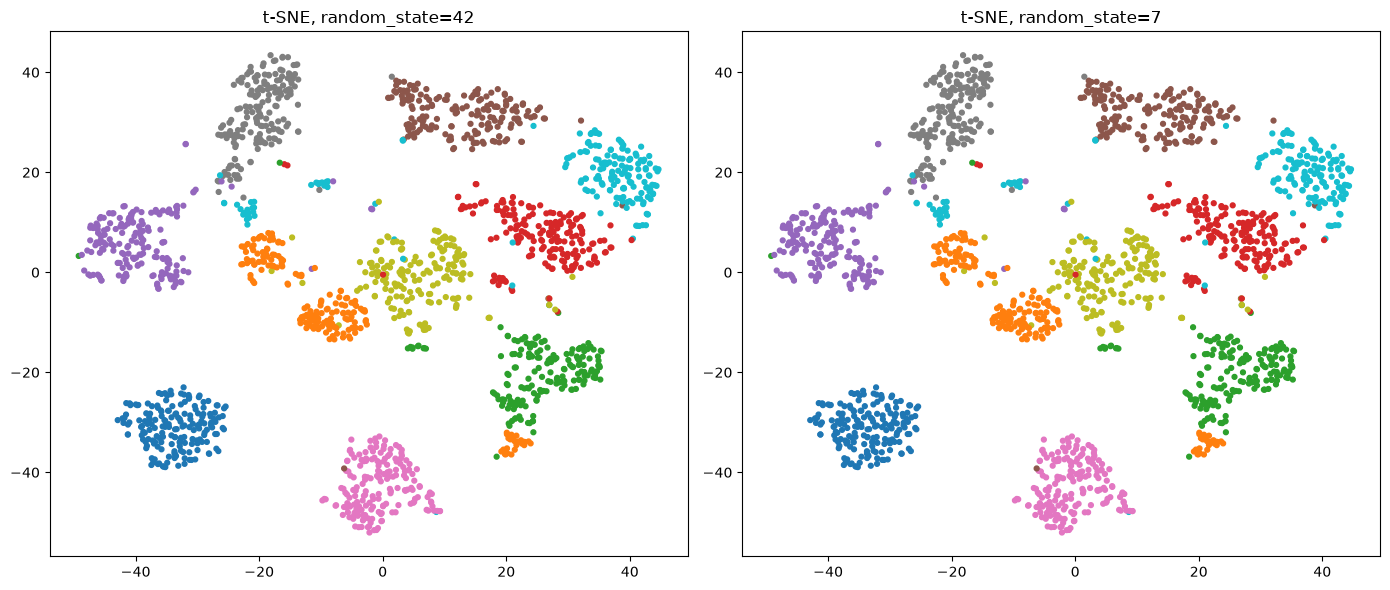

Layouts differ (different orientation/spacing) but the same digits still cluster together in both --
the GROUPING is meaningful and reproducible, the exact coordinates/distances are not.


In [5]:
# Important caveat: distances between t-SNE clusters and cluster SIZES are not meaningful,
# only the neighborhood/grouping structure is. Re-running with a different seed changes
# the layout (rotation, scale, relative positions) while preserving groupings.
tsne_seed2 = TSNE(n_components=2, perplexity=30, random_state=7, init='pca')
X_tsne_seed2 = tsne_seed2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=12)
axes[0].set_title('t-SNE, random_state=42')
axes[1].scatter(X_tsne_seed2[:, 0], X_tsne_seed2[:, 1], c=y, cmap='tab10', s=12)
axes[1].set_title('t-SNE, random_state=7')
plt.tight_layout()
plt.show()
print("Layouts differ (different orientation/spacing) but the same digits still cluster together in both --")
print("the GROUPING is meaningful and reproducible, the exact coordinates/distances are not.")